In [1]:
# 1. Load basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# 2. Load dataset (Iris dataset)
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
df = pd.read_csv(url)

In [3]:
# 3. Analyse dataset
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistics:\n", df.describe())

First 5 rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistics:
        sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   

In [4]:
# 4. Pre-process data
# Convert categorical labels into numbers
df['species'] = df['species'].astype('category').cat.codes

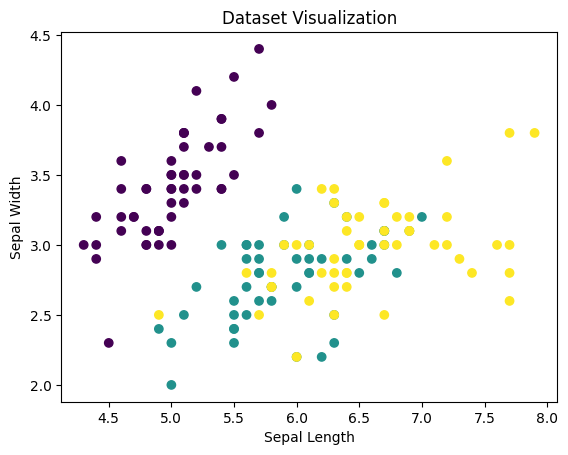

In [5]:

# 5. Visualize data (simple scatter plot)
plt.scatter(df['sepal_length'], df['sepal_width'], c=df['species'])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Dataset Visualization")
plt.show()

In [8]:
# 6. Separate features and target
X = df.iloc[:, :-1].values   # all columns except last
y = df.iloc[:, -1].values    # last column (species)

# Split dataset into training and test manually
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
# 7. Select value of K
K = 5

In [10]:
# 8. Euclidean Distance Function
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

In [11]:
# 9-11. KNN Algorithm
def knn_predict(X_train, y_train, x_test, K):
    distances = []

    # Calculate distance from all training points
    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], x_test)
        distances.append((dist, y_train[i]))

    # Sort based on distance
    distances.sort(key=lambda x: x[0])

    # Take K nearest neighbors
    neighbors = distances[:K]

    # Count categories
    labels = [label for (_, label) in neighbors]

    # Majority voting
    prediction = Counter(labels).most_common(1)[0][0]

    return prediction

In [12]:
# 12. Model testing
predictions = []

for i in range(len(X_test)):
    pred = knn_predict(X_train, y_train, X_test[i], K)
    predictions.append(pred)

# Accuracy calculation
accuracy = np.sum(predictions == y_test) / len(y_test)
print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.8
